# SHAP Explainability Notebook

Global and local feature importance from a trained model.joblib

In [9]:

import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


In [10]:

MODEL_PATH = "../model/best_model_lightGBM.joblib"
TRAIN_CSV_PATH = "../data/raw/application_train.csv"
ID_COL = "SK_ID_CURR"
CLIENT_ID = 100002  # set to None if no local explanation
BACKGROUND_SIZE = 1000
OUT_PREFIX = "credit"

## Load trained best model

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # monte d'un niveau (../)
from src.config import PATHS
from src.data import load_parquet

artifact = joblib.load(MODEL_PATH)
pipe = artifact["model"]

# df = pd.read_csv(TRAIN_CSV_PATH)
df = load_parquet(PATHS.data_processed / "train_fe.parquet")
if "TARGET" in df.columns:
    df = df.drop(columns=["TARGET"])
    print("TARGET column was dropped")

pre = pipe.named_steps["pre"]
model = pipe.named_steps["model"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = None

print("Model loaded")
print("Data shape:", df.shape)


TARGET column was dropped
Model loaded
Data shape: (99999, 125)


## SHAP global importance beeswarm / global summary

In [12]:

def ensure_dense(X):
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return np.asarray(X)

bg = df.sample(min(BACKGROUND_SIZE, len(df)), random_state=42)
X_bg_trans = ensure_dense(pre.transform(bg))

explainer = shap.TreeExplainer(model)
shap_bg = explainer.shap_values(X_bg_trans)
base_value = explainer.expected_value

print("SHAP global computed")


SHAP global computed


C:\apps\anaconda3\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


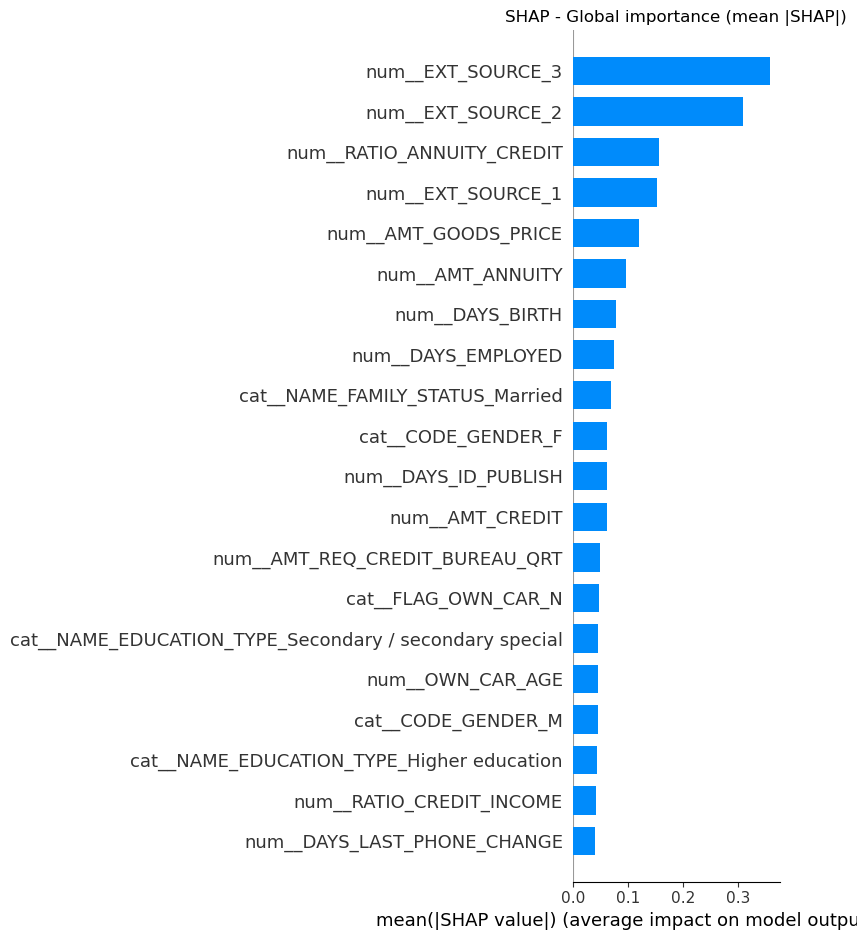

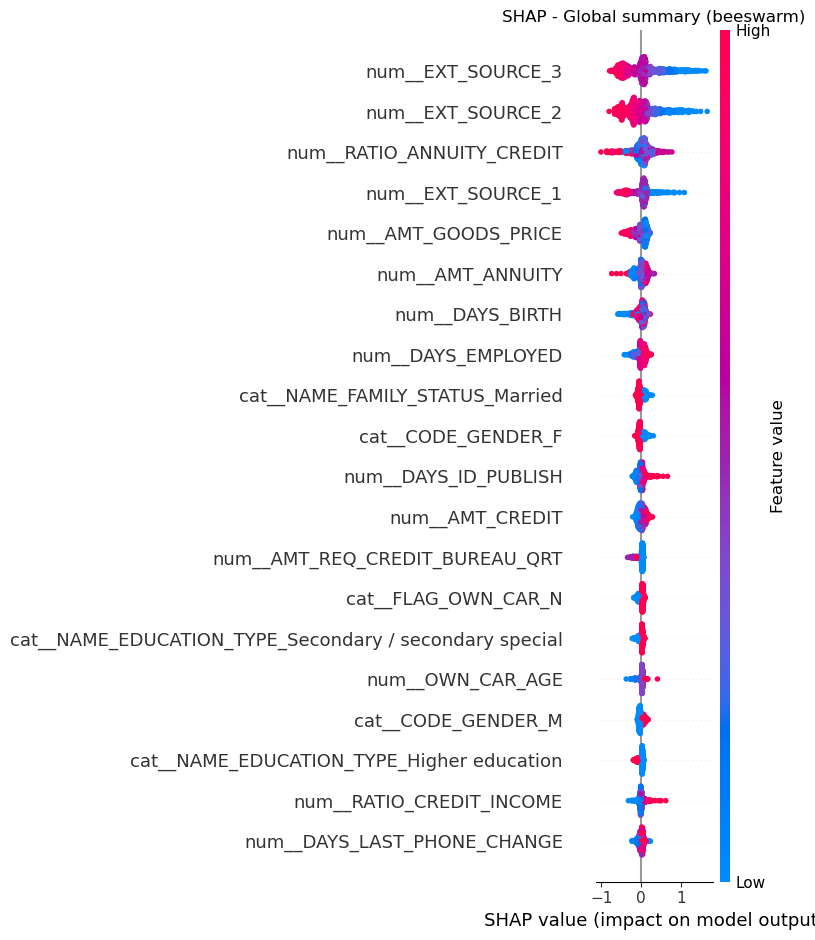

,feature,mean_abs_shap
30,num__EXT_SOURCE_3,0.357606
29,num__EXT_SOURCE_2,0.309358
106,num__RATIO_ANNUITY_CREDIT,0.155939
28,num__EXT_SOURCE_1,0.151781
5,num__AMT_GOODS_PRICE,0.120603
4,num__AMT_ANNUITY,0.096626
7,num__DAYS_BIRTH,0.079071
8,num__DAYS_EMPLOYED,0.074674
139,cat__NAME_FAMILY_STATUS_Married,0.069002
110,cat__CODE_GENDER_F,0.062753


In [13]:

plt.figure()
shap.summary_plot(
    shap_bg,
    features=X_bg_trans,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP - Global importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_global_bar.png", dpi=200)
plt.show()

plt.figure()
shap.summary_plot(
    shap_bg,
    features=X_bg_trans,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Global summary (beeswarm)")
plt.tight_layout()
plt.savefig(f"{OUT_PREFIX}_global_beeswarm.png", dpi=200)
plt.show()

n_features = shap_bg.shape[1]
names = list(feature_names) if feature_names is not None else [f"f{i}" for i in range(n_features)]

global_df = (
    pd.DataFrame({"feature": names, "mean_abs_shap": np.abs(shap_bg).mean(axis=0)})
    .sort_values("mean_abs_shap", ascending=False)
)
global_df.to_csv(f"{OUT_PREFIX}_global_importance.csv", index=False)
global_df.head(15)


In [14]:
global_df["feature"].head(15).tolist()

['num__EXT_SOURCE_3',
 'num__EXT_SOURCE_2',
 'num__RATIO_ANNUITY_CREDIT',
 'num__EXT_SOURCE_1',
 'num__AMT_GOODS_PRICE',
 'num__AMT_ANNUITY',
 'num__DAYS_BIRTH',
 'num__DAYS_EMPLOYED',
 'cat__NAME_FAMILY_STATUS_Married',
 'cat__CODE_GENDER_F',
 'num__DAYS_ID_PUBLISH',
 'num__AMT_CREDIT',
 'num__AMT_REQ_CREDIT_BUREAU_QRT',
 'cat__FLAG_OWN_CAR_N',
 'cat__NAME_EDUCATION_TYPE_Secondary / secondary special']

In [15]:
import numpy as np
import pandas as pd

# Récupération des noms des features après preprocessing
feature_names = pre.get_feature_names_out()

# Cas classification binaire : SHAP peut retourner une liste [classe 0, classe 1]
if isinstance(shap_bg, list):
    shap_values_global = shap_bg[1]  # classe positive
else:
    shap_values_global = shap_bg

# Si SHAP retourne un tableau 3D : (samples, features, classes)
if len(shap_values_global.shape) == 3:
    shap_values_global = shap_values_global[:, :, 1]

# Importance globale SHAP = moyenne des valeurs absolues
shap_importance = np.abs(shap_values_global).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance
})

# Tri décroissant
shap_importance_df = shap_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

# Calcul importance relative et cumulée
shap_importance_df["importance_ratio"] = (
    shap_importance_df["importance"] / shap_importance_df["importance"].sum()
)

shap_importance_df["cumulative_importance"] = (
    shap_importance_df["importance_ratio"].cumsum()
)

# Sélection des features couvrant 80%
THRESHOLD = 0.80

selected_features_80 = shap_importance_df[
    shap_importance_df["cumulative_importance"] <= THRESHOLD
]["feature"].tolist()

# Ajouter la première feature qui dépasse 80%
if len(selected_features_80) < len(shap_importance_df):
    selected_features_80.append(
        shap_importance_df.iloc[len(selected_features_80)]["feature"]
    )

print(f"Nombre de features retenues pour couvrir {THRESHOLD:.0%} de l'importance SHAP :")
print(len(selected_features_80))

print("\nFeatures sélectionnées :")
for feature in selected_features_80:
    print("-", feature)

display(shap_importance_df.head(30))

Nombre de features retenues pour couvrir 80% de l'importance SHAP :
38

Features sélectionnées :
- num__EXT_SOURCE_3
- num__EXT_SOURCE_2
- num__RATIO_ANNUITY_CREDIT
- num__EXT_SOURCE_1
- num__AMT_GOODS_PRICE
- num__AMT_ANNUITY
- num__DAYS_BIRTH
- num__DAYS_EMPLOYED
- cat__NAME_FAMILY_STATUS_Married
- cat__CODE_GENDER_F
- num__DAYS_ID_PUBLISH
- num__AMT_CREDIT
- num__AMT_REQ_CREDIT_BUREAU_QRT
- cat__FLAG_OWN_CAR_N
- cat__NAME_EDUCATION_TYPE_Secondary / secondary special
- num__OWN_CAR_AGE
- cat__CODE_GENDER_M
- cat__NAME_EDUCATION_TYPE_Higher education
- num__RATIO_CREDIT_INCOME
- num__DAYS_LAST_PHONE_CHANGE
- num__FLAG_PHONE
- num__RATIO_EMPLOYED_BIRTH
- num__FLAG_DOCUMENT_3
- num__DEF_60_CNT_SOCIAL_CIRCLE
- num__DAYS_REGISTRATION
- num__HOUR_APPR_PROCESS_START
- num__AMT_INCOME_TOTAL
- num__REGION_RATING_CLIENT_W_CITY
- num__REGION_POPULATION_RELATIVE
- num__SK_ID_CURR
- num__YEARS_BEGINEXPLUATATION_MODE
- cat__NAME_INCOME_TYPE_Working
- num__DEF_30_CNT_SOCIAL_CIRCLE
- num__TOTALAREA_

,feature,importance,importance_ratio,cumulative_importance
0,num__EXT_SOURCE_3,0.357606,0.120258,0.120258
1,num__EXT_SOURCE_2,0.309358,0.104033,0.224291
2,num__RATIO_ANNUITY_CREDIT,0.155939,0.052440,0.276731
3,num__EXT_SOURCE_1,0.151781,0.051042,0.327773
4,num__AMT_GOODS_PRICE,0.120603,0.040557,0.368330
5,num__AMT_ANNUITY,0.096626,0.032494,0.400824
6,num__DAYS_BIRTH,0.079071,0.026591,0.427415
7,num__DAYS_EMPLOYED,0.074674,0.025112,0.452526
8,cat__NAME_FAMILY_STATUS_Married,0.069002,0.023205,0.475731
9,cat__CODE_GENDER_F,0.062753,0.021103,0.496834


## Local SHAP waterfall for choosen CLIENT_ID

C:\apps\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\apps\anaconda3\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


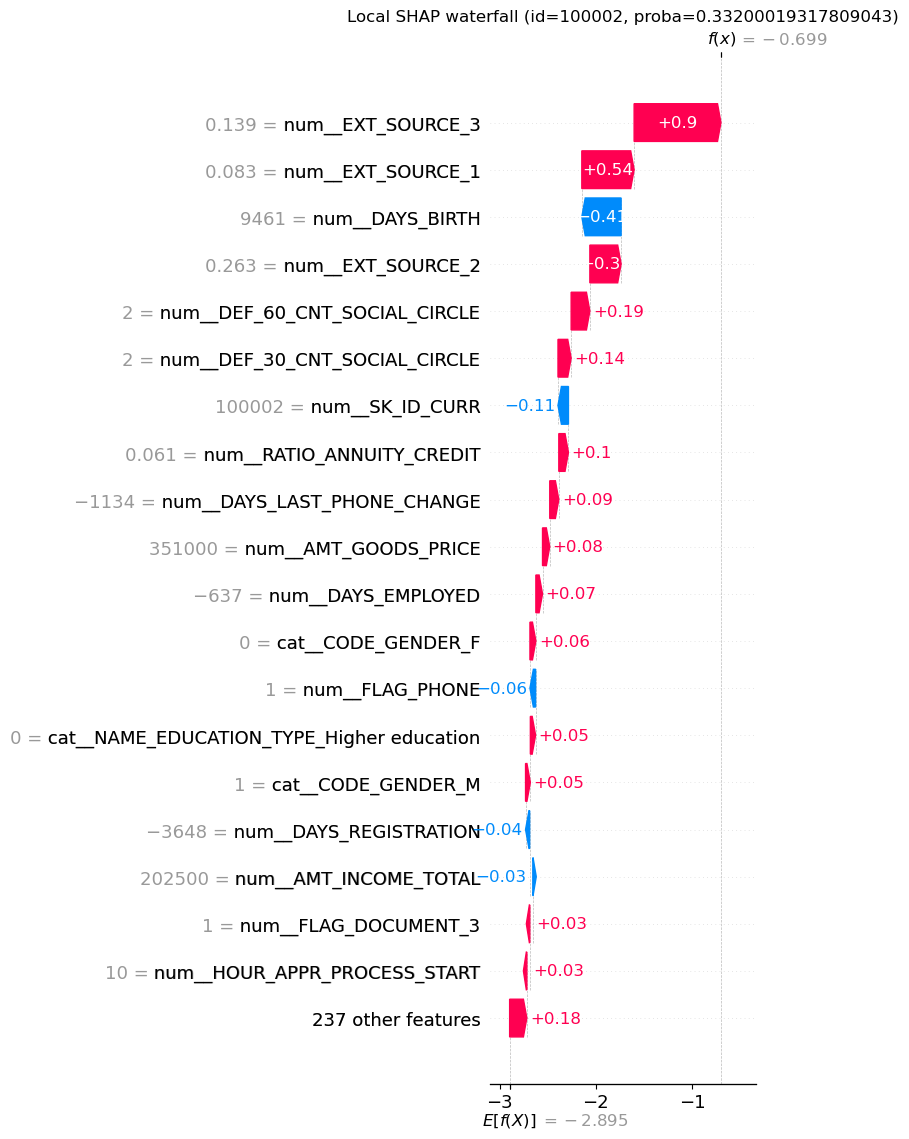

In [16]:

if CLIENT_ID is not None:
    rows = df[df[ID_COL] == CLIENT_ID]
    if rows.empty:
        raise ValueError("Client not found")

    x_one = rows.iloc[[0]]
    proba = float(pipe.predict_proba(x_one)[0, 1]) if hasattr(pipe, "predict_proba") else None

    X_one_trans = ensure_dense(pre.transform(x_one))
    shap_one = explainer.shap_values(X_one_trans)
    shap_row = shap_one[0]
    x_row = X_one_trans[0]

    exp = shap.Explanation(
        values=shap_row,
        base_values=base_value,
        data=x_row,
        feature_names=feature_names
    )

    plt.figure()
    shap.plots.waterfall(exp, show=False, max_display=20)
    plt.title(f"Local SHAP waterfall (id={CLIENT_ID}, proba={proba})")
    plt.tight_layout()
    plt.savefig(f"{OUT_PREFIX}_local_waterfall_{CLIENT_ID}.png", dpi=200)
    plt.show()

    local_df = (
        pd.DataFrame({
            "feature": names,
            "value_transformed": x_row,
            "shap": shap_row,
            "abs_shap": np.abs(shap_row)
        })
        .sort_values("abs_shap", ascending=False)
    )
    local_df.to_csv(f"{OUT_PREFIX}_local_contrib_{CLIENT_ID}.csv", index=False)

    summary = {
        "client_id": CLIENT_ID,
        "proba": proba,
        "top10": local_df.head(10)[["feature", "shap", "abs_shap"]].to_dict(orient="records")
    }
    with open(f"{OUT_PREFIX}_local_summary_{CLIENT_ID}.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    local_df.head(15)
else:
    print("No local explanation requested")
